In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# Load the dataset

In [2]:
data = pd.read_csv("bank-additional-full.csv", sep=";")
data.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

In [4]:
X = data.drop('y', axis=1)
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

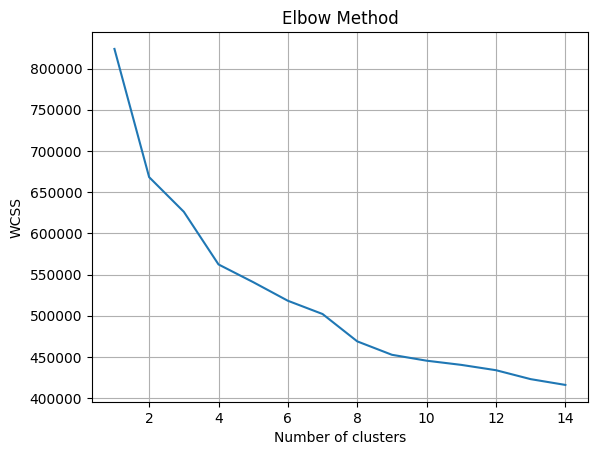

In [5]:
wcss = [] # Within-Cluster-Sum of Squares
for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 15), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

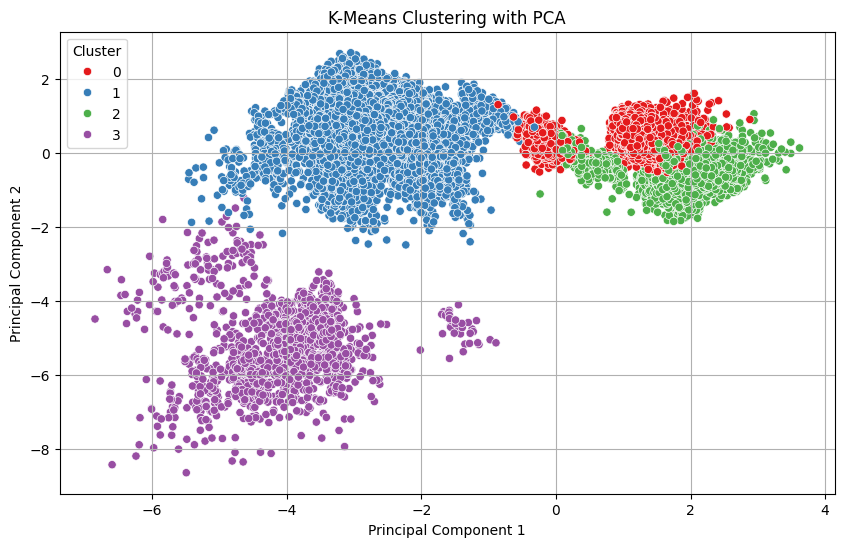

In [6]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["clusters"] = clusters
cluster_profiles = data.groupby("clusters").mean(numeric_only=True)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set1')
plt.title('K-Means Clustering with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


In [7]:
print(cluster_profiles)

                age       job   marital  education   default   housing  \
clusters                                                                 
0         40.137621  3.850911  1.153512   4.022262  0.222247  1.121055   
1         39.495198  3.700047  1.242639   3.784050  0.113368  1.154070   
2         40.201996  3.565559  1.113361   3.386749  0.303324  0.940715   
3         41.856201  4.248021  1.290897   4.257916  0.042216  1.125330   

              loan   contact     month  day_of_week  ...  campaign  \
clusters                                             ...             
0         0.335957  0.003673  3.008620     2.102766  ...  2.763886   
1         0.328373  0.098646  4.475437     1.914108  ...  2.111085   
2         0.318365  1.000000  5.136400     1.985399  ...  2.883777   
3         0.325858  0.074538  4.796834     2.071900  ...  1.822559   

               pdays  previous  poutcome  emp.var.rate  cons.price.idx  \
clusters                                                    

In [8]:
def marketing_strategy(cluster_profiles):
    strategies = {}

    for cluster, profile in cluster_profiles.iterrows():

        if profile['euribor3m'] > 4.5 and profile['previous'] < 0.1:
            strategies[cluster] = "Awareness Campaign: Digital marketing, email campaign, product education"

        elif profile['campaign'] > 2.5 and profile['previous'] > 0:
            strategies[cluster] = "Conversion Strategy: Promote loans, credit cards, and limited-time offers"

        elif profile['campaign'] > 2.5 and profile['previous'] == 0:
            strategies[cluster] = "Re-targeting Strategy: Change marketing approach, reduce frequency, use new channels"

        elif profile['euribor3m'] < 2 and profile['previous'] > 0.3:
            strategies[cluster] = "High Value Customers: Offer investment, deposito, and priority banking"

        else:
            strategies[cluster] = "General Strategy: Standard marketing approach"

    return strategies

In [9]:
stratgies = marketing_strategy(cluster_profiles)
for cluster, strategy in stratgies.items():
    print(f"Cluster {cluster}: {strategy}")

Cluster 0: Awareness Campaign: Digital marketing, email campaign, product education
Cluster 1: High Value Customers: Offer investment, deposito, and priority banking
Cluster 2: Awareness Campaign: Digital marketing, email campaign, product education
Cluster 3: High Value Customers: Offer investment, deposito, and priority banking


In [11]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns, "features.pkl")
joblib.dump(X_scaled, "X_scaled.pkl")
joblib.dump(clusters, "clusters.pkl")

['clusters.pkl']